In [1]:
!pip install scikit-image watermark -q

In [2]:
import numpy as np
import cv2
from cv2 import imread
import matplotlib.pyplot as plt

[OpenCV](https://opencv.org/) ("Open Computer Vision") es una librería de código abierto para visión por computadora desarrollada originalmente por Intel. Está implementada en `C++`, ofrece APIs en múltiples lenguajes y cuenta con soporte multiplataforma. Es una de las librerías más utilizadas en visión artificial e incluye una gran cantidad de herramientas para procesar imágenes y video.

[watermark](https://github.com/rasbt/watermark) es una extensión de las funciones mágicas de Jupyter que permite verificar con facilidad la versión de Python y de las librerías instaladas.

In [3]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2026-04-07T16:10:12.189217-03:00

Python implementation: CPython
Python version       : 3.12.6
IPython version      : 9.12.0

Compiler    : MSC v.1940 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 151 Stepping 2, GenuineIntel
CPU cores   : 12
Architecture: 64bit

cv2       : 4.13.0
matplotlib: 3.10.8
numpy     : 2.4.4



## Imagen de entrada

In [4]:
!wget https://d1lfxha3ugu3d4.cloudfront.net/images/opencollection/archives/size2/S03i3165l01.jpg

#https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.coins
#wget https://opencollection.brooklynmuseum.org/archives/image/51611

Descargado: S03i3165l01.jpg


## Leer y mostrar la imagen

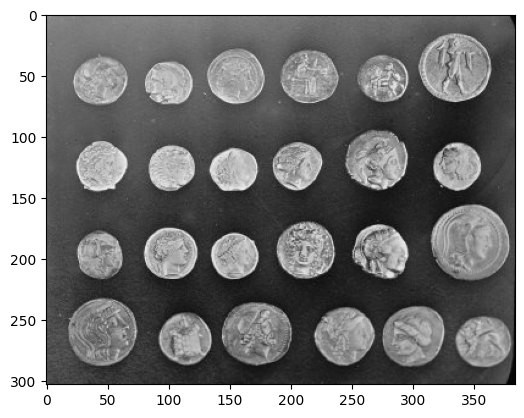

In [5]:
img = imread('/content/S03i3165l01.jpg')
plt.imshow(img)
plt.show()

In [6]:
type(img)

numpy.ndarray

## Función: ¿cómo es esta imagen?

In [7]:
def data_img(img):
  print('dimensiones = ', img.shape)
  print('máximo      = ', np.max(img))
  print('mínimo      = ', np.min(img))

data_img(img)

dimensiones =  (303, 384, 3)
máximo      =  252
mínimo      =  1


¿Qué representan estas dimensiones?

La función `data_img` muestra la forma de la imagen a través de `img.shape`. Esta tupla indica las dimensiones de la imagen. Las dos primeras corresponden al alto y al ancho, respectivamente. Por ejemplo, si `img.shape` devuelve `(305, 200, 3)`, eso significa que la imagen tiene 305 píxeles de alto, 200 píxeles de ancho y 3 canales de color.

## Recorte

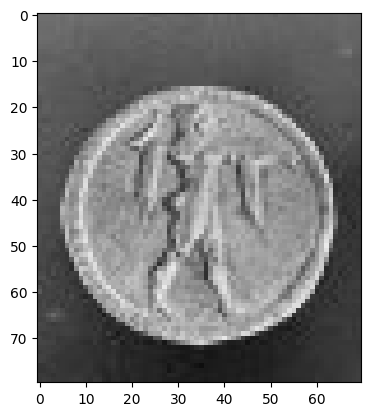

In [8]:
# Primero alto, después ancho
img_cropped = img[0:80, 300:370]
plt.imshow(img_cropped)

In [9]:
data_img(img_cropped)

dimensiones =  (80, 70, 3)
máximo      =  234
mínimo      =  14


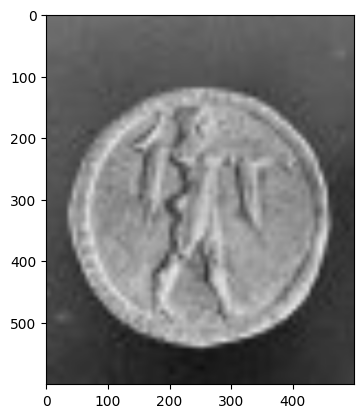

In [10]:
# Primero ancho y después alto
img_resize = cv2.resize(img_cropped, (500, 600))
plt.imshow(img_resize)

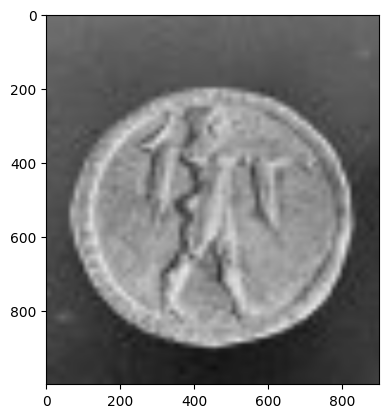

In [11]:
# Primero ancho y después alto
img_resize = cv2.resize(img_cropped, (900, 1000))
plt.imshow(img_resize)

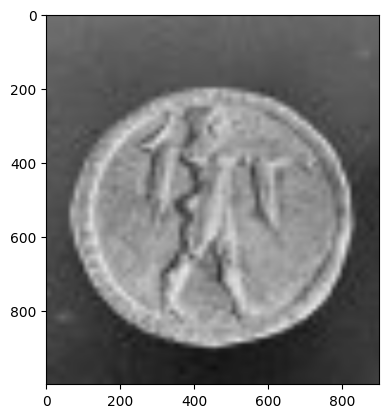

In [12]:
imgResizeA = cv2.resize(img_cropped, (200, 300))
plt.imshow(img_resize)

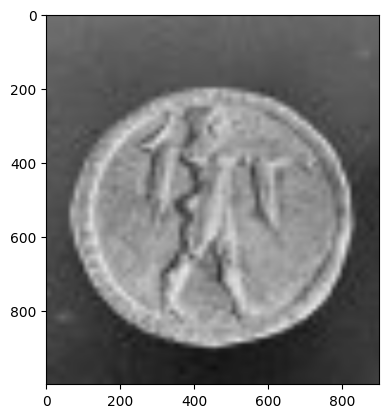

In [13]:
imgResizeB = cv2.resize(img_cropped, (700, 800))
plt.imshow(img_resize)

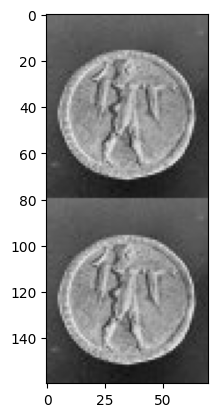

In [14]:
# Apilado vertical
vertical = np.vstack((img_cropped, img_cropped
                 ))
plt.imshow(vertical);

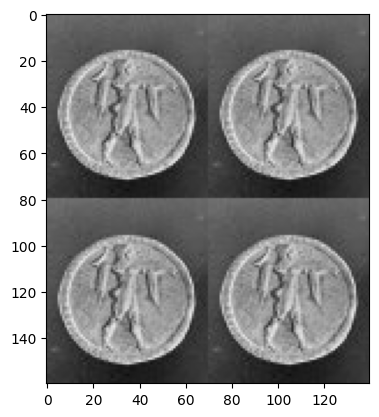

In [15]:
# Apilamos horizontalmente dos filas para generar una matriz de 2x2
horizontal = np.hstack((vertical, vertical))
plt.imshow(horizontal);

## Selección del primer canal

In [16]:
X = img_cropped[:,:,0]
data_img(X)

dimensiones =  (80, 70)
máximo      =  234
mínimo      =  14


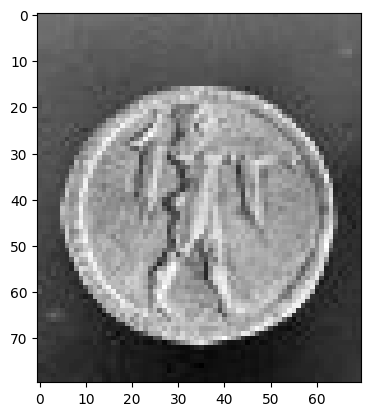

In [17]:
plt.imshow(X,cmap='gray')
plt.show()

Para usar esta función llamamos a [`cv2.Canny()`](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html). El primer parámetro es la imagen en la que queremos detectar los bordes. El segundo y el tercer parámetro configuran la sensibilidad del algoritmo. Valores típicos son: `(100, 200)`, `(50, 100)`, `(150, 200)`. El tercero debe ser más alto que el primero (uno es un mínimo y otro es un máximo). Valores bajos harán al algoritmo más sensible (esto es, detectará más bordes) y valores más altos harán que detecte menos bordes.

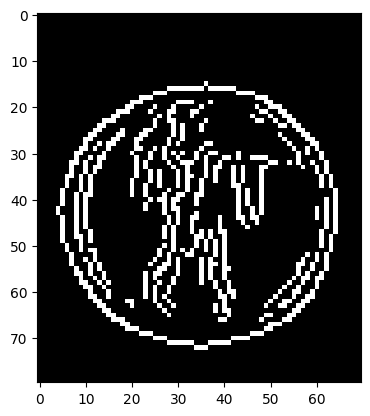

In [18]:
img_canny = cv2.Canny(img_cropped, 200, 250)
plt.imshow(img_canny, cmap='gray');

En OpenCV y NumPy, las imágenes a color se almacenan como arreglos de tres dimensiones:

* Primera dimensión (altura): número de filas
* Segunda dimensión (ancho): número de columnas
* Tercera dimensión (canales): 3 valores para BGR (Blue, Green, Red)

La notación `[:,:,0]` usa el indexado de NumPy de la siguiente manera:

* `:` significa "tomar todos los elementos" de esa dimensión
* `0` significa "tomar solo el primer canal"

Por ejemplo, si tenemos una imagen de 100x200 píxeles:

* `img_cropped[:, :, 0]` - Canal azul (primer canal en BGR)
* `img_cropped[:, :, 1]` - Canal verde (segundo canal)
* `img_cropped[:, :, 2]` - Canal rojo (tercer canal)

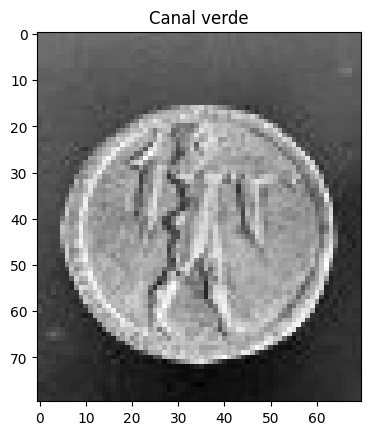

In [19]:
# Canal verde
X_green = img_cropped[:,:,1]
plt.imshow(X_green, cmap='gray')
plt.title('Canal verde')
plt.show()

In [20]:
!wget https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300/html/images/plain/normal/color/124084.jpg

Descargado: 124084.jpg


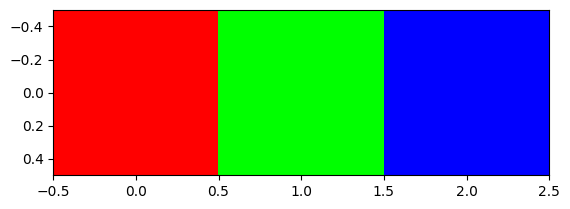

In [21]:
# Máximo rojo, sin verde ni azul: rojo
pixel1 = (255, 0, 0)

# Máximo verde, sin rojo ni azul: verde
pixel2 = (0, 255, 0)

# Máximo azul, sin rojo ni verde: azul
pixel3 = (0, 0, 255)

plt.imshow([[pixel1, pixel2, pixel3]]);

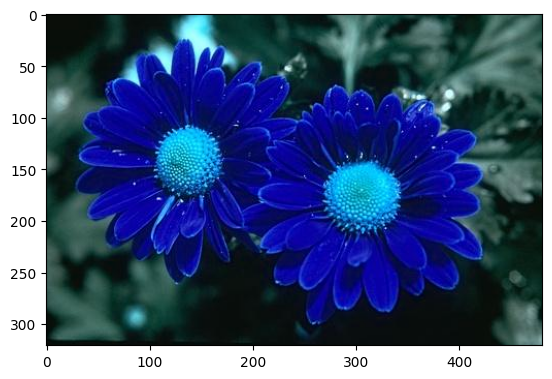

In [22]:
img = imread('124084.jpg')
plt.imshow(img)
plt.show()

In [23]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [24]:
img[0, 0]

array([10, 14,  9], dtype=uint8)

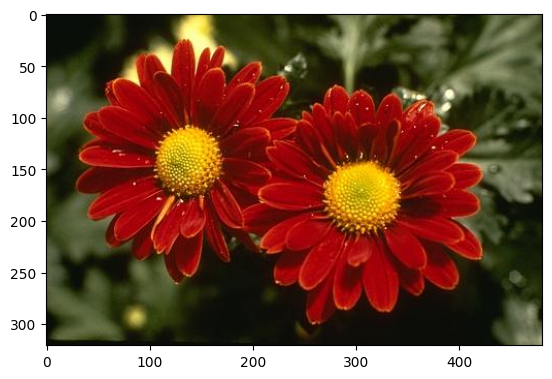

In [25]:
plt.imshow(img_rgb);

## Umbralización: segmentación simple

In [26]:
def segmenta(X,t):
    # X: imagen de entrada (matriz 2D)
    # t: valor de umbral

    (N,M) = X.shape  # Obtiene dimensiones de la imagen
    Y = np.zeros((N,M))  # Crea una matriz de ceros del mismo tamaño
    area = 0  # Inicializa el contador de píxeles

    # Recorre cada píxel de la imagen
    for i in range(N):  # Recorre filas
        for j in range(M):  # Recorre columnas
            if X[i,j] > t:  # Si el píxel supera el umbral
                Y[i,j] = 255  # Lo marca como blanco
                area = area + 1  # Incrementa el contador

    print('area = ',area)  # Imprime el área total
    return Y  # Devuelve la imagen segmentada

## Segmentación

area =  484
dimensiones =  (80, 70)
máximo      =  255.0
mínimo      =  0.0


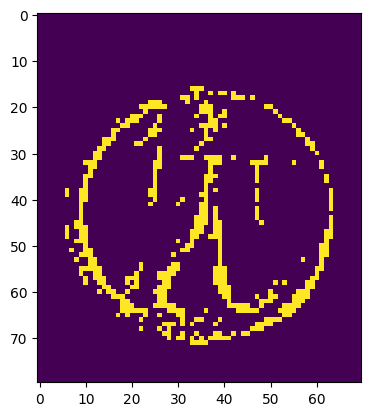

In [27]:
# 1. Llamada a la función de segmentación
Y = segmenta(X, 180)  # Segmenta la imagen con un umbral de 180

# 2. Analiza las propiedades de la imagen resultante
data_img(Y)

# 3. Visualiza la imagen segmentada
plt.imshow(Y)
plt.show()

# Todas las monedas

dimensiones =  (303, 384)
máximo      =  252
mínimo      =  1


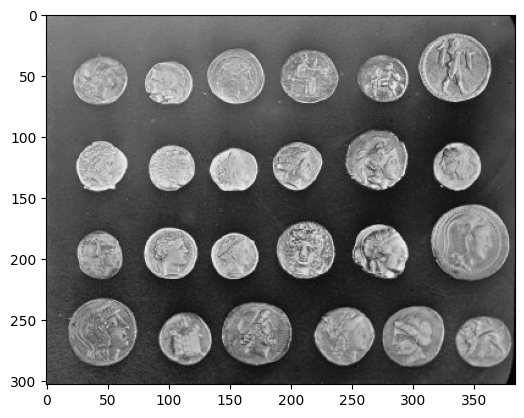

In [28]:
full_img = imread('S03i3165l01.jpg')
X   = full_img[:,:,0]
data_img(X)
plt.imshow(X,cmap='gray')
plt.show()

area =  48864


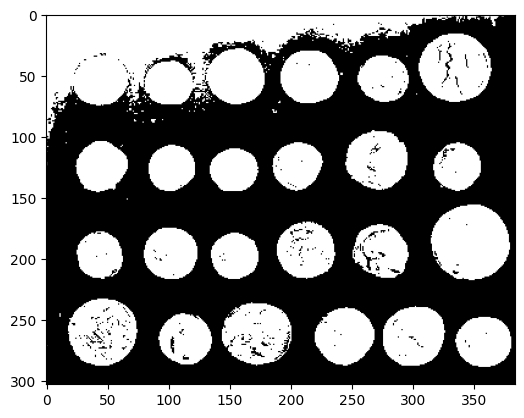

In [29]:
Y = segmenta(X, 100)
plt.imshow(Y,cmap='gray')
plt.show()

area =  23765


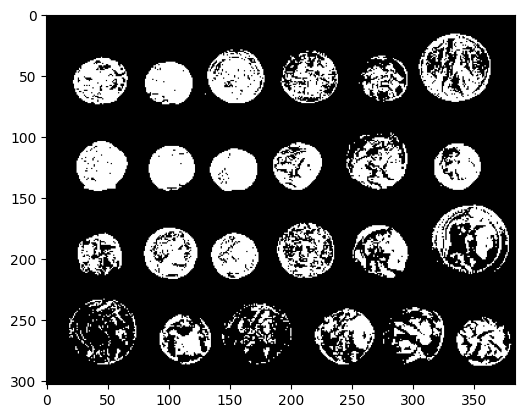

In [30]:
Y = segmenta(X,150)
plt.imshow(Y,cmap='gray')
plt.show()

## Definición de un fondo homogéneo

El propósito de este código es:

* Normalizar la iluminación por filas
* Reducir variaciones de fondo
* Mejorar el contraste local
* Facilitar la segmentación posterior

Por ejemplo:

Si una fila tiene valores [100, 120, 150] y el mínimo es 100 después de la normalización: [0, 20, 50]

Esto es útil cuando:

* Hay variaciones de iluminación en la imagen
* El fondo no es uniforme
* Se necesita resaltar objetos sobre el fondo
* Se quiere preparar la imagen para segmentación

La imagen resultante tendrá:

* Fondo más uniforme
* Objetos más destacados
* Mejor contraste local
* Más facilidad para aplicar umbralización

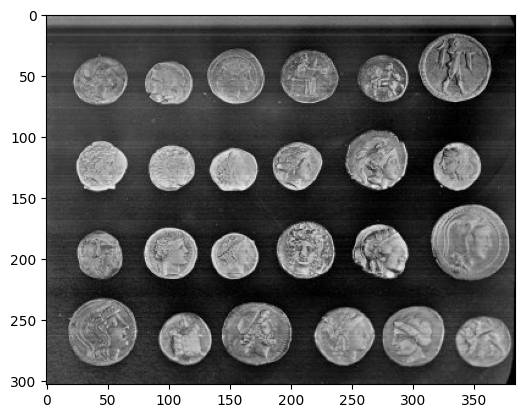

In [31]:
# 1. Obtiene las dimensiones de la imagen
(N,M) = X.shape  # N = número de filas, M = número de columnas

# 2. Crea una matriz vacía del mismo tamaño
Xm = np.zeros((N,M), np.uint8)  # Matriz de ceros de 8 bits

# 3. Procesa cada fila de la imagen
for i in range(N):
    xmin = np.min(X[i,:])  # Encuentra el valor mínimo de la fila
    Xm[i,:] = X[i,:] - xmin  # Resta el mínimo a toda la fila

# 4. Visualiza el resultado
plt.imshow(Xm, cmap='gray')
plt.show()

area =  37003


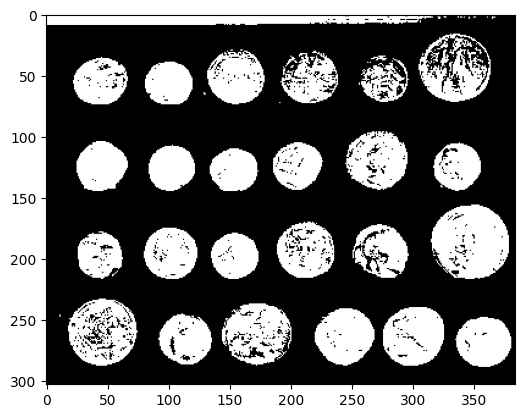

In [32]:
Y = segmenta(Xm, 100)
plt.imshow(Y,cmap='gray')
plt.show()